<a href="https://colab.research.google.com/github/morganhenshaw/NLSTRadiomics/blob/main/create_metadata_table.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install idc-index

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.4/85.4 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 76.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 86.3 MB/s eta 0:00:00
  Attempting uninstall: duckdb
    Found existing installation: duckdb 1.3.2
    Uninstalling duckdb-1.3.2:
      Successfully uninstalled duckdb-1.3.2


In [3]:
from idc_index import IDCClient
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
c = IDCClient()

c.fetch_index('clinical_index')

print('Columns available in clinical_index:\n' + '\n'.join(c.clinical_index.keys()))

Columns available in clinical_index:
collection_id
table_name
short_table_name
column
column_label
values


In [5]:
# Accessing clinical metadata
nlst_clinical_data_columns = c.clinical_index[c.clinical_index['collection_id'] == 'nlst']
nlst_clinical_data_columns[['short_table_name', 'column', 'column_label', 'values']]

,short_table_name,column,column_label,values
7184,nlst_canc,dicom_patient_id,idc_provenance_dicom_patient_id,[]
7185,nlst_canc,source_batch,idc_provenance_source_batch,"[{'option_code': '0', 'option_description': No..."
7186,nlst_canc,pid,pid,[]
7187,nlst_canc,lc_topog,ICD-O-3 Topography: ICD-O-3 topography of lung...,"[{'option_code': 'C34.0', 'option_description'..."
7188,nlst_canc,topog_source,Source of samples for ICD-O-3 code: Indicates ...,"[{'option_code': '.M', 'option_description': '..."
...,...,...,...,...
7304,nlst_screen,ctdxqual_graininess,Reason for limited / non-diagnostic CT: Excess...,"[{'option_code': '.N', 'option_description': '..."
7305,nlst_screen,ctdxqual_other,Reason for limited / non-diagnostic CT: Other ...,"[{'option_code': '.N', 'option_description': '..."
7306,nlst_screen,ct_recon_filter3,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."
7307,nlst_screen,ct_recon_filter4,CT reconstruction algorithm / filter: What CT ...,"[{'option_code': '.M', 'option_description': '..."


In [6]:
# Search column names and labels keywords to identify metadata of interest
stage_columns = nlst_clinical_data_columns[nlst_clinical_data_columns['column_label'].str.contains('stage', case=False, na=False)]
stage_columns

,collection_id,table_name,short_table_name,column,column_label,values
7191,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag,"Stage (""Best"": Path if avail., else Clin): Lun...","[{'option_code': '.M', 'option_description': '..."
7192,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,path_stag,Pathologic Stage: Pathologic stage of lung can...,"[{'option_code': '.M', 'option_description': '..."
7193,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,clinical_stag,Clinical Stage: Clinical stage of lung cancer ...,"[{'option_code': '.M', 'option_description': '..."
7194,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_sum,Summary staging: Summary staging.For all ACRIN...,"[{'option_code': '.M', 'option_description': '..."
7195,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,valcsg,VALCSG Stage (Small cell only): VALCSG staging...,"[{'option_code': '.M', 'option_description': '..."
7202,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."
7208,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,source_best_stage,"Source of ""best"" stage (de_stag): Describes wh...","[{'option_code': '1', 'option_description': 'P..."
7215,nlst,bigquery-public-data.idc_v23_clinical.nlst_canc,nlst_canc,stage_only,"Stage Only (if separate T, N, & M not availabl...","[{'option_code': '.M', 'option_description': '..."
7269,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag,"Lung cancer Stage: Lung cancer stage (AJCC 6),...","[{'option_code': '.M', 'option_description': '..."
7286,nlst,bigquery-public-data.idc_v23_clinical.nlst_prsn,nlst_prsn,de_stag_7thed,AJCC 7th edition stage: Stage of first primary...,"[{'option_code': '.M', 'option_description': '..."


In [7]:
# Access nlst_canc table
nlst_canc_df = c.get_clinical_table("nlst_canc")
nlst_canc_df

,dicom_patient_id,source_batch,pid,lc_topog,topog_source,de_type,de_grade,de_stag,path_stag,clinical_stag,...,path_t,clinical_n,path_n,clinical_m,path_m,stage_only,study_yr,dataset_version,lc_order,candx_days
0,102266,0,102266,C34.1,,8046,4,110,,,...,,,,,,110,0,2011.02.03/05.12.21,1,69
1,118193,0,118193,C34.9,4,,1,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,128
2,119813,0,119813,C34.9,1,8046,8,888,,,...,,,,,,888,0,2011.02.03/05.12.21,1,18
3,125998,0,125998,C34.2,2,8046,8,,,,...,,,,,,,0,2011.02.03/05.12.21,1,212
4,102161,0,102161,C34.1,,8013,4,110,110,,...,100,,0,,0,110,0,2011.02.03/05.12.21,1,22
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2145,210195,0,210195,C34.2,1,8070,4,900,999,999,...,999,0,,0,,,5,2011.02.03/05.12.21,2,1957
2146,210218,0,210218,C34.2,,8240,9,999,999,999,...,999,999,999,999,999,,2,2011.02.03/05.12.21,1,1024
2147,213639,0,213639,C34.3,3,8046,4,400,999,999,...,999,200,999,0,999,400,1,2011.02.03/05.12.21,1,721
2148,214850,0,214850,C34.8,2,8041,5,999,999,999,...,999,100,999,0,999,,4,2011.02.03/05.12.21,1,1751


In [8]:
# What are values of attribute clinical_stag?
print(nlst_canc_df['clinical_stag'].unique())

# Make them human readable
clinical_stag_values = nlst_clinical_data_columns[nlst_clinical_data_columns['column']=='clinical_stag']['values'].values[0]
print(clinical_stag_values)

['' '110' '120' '210' '220' '310' '320' '400' '888' '900' '994' '999']
[{'option_code': '.M', 'option_description': 'Missing'}
 {'option_code': '110', 'option_description': 'Stage IA'}
 {'option_code': '120', 'option_description': 'Stage IB'}
 {'option_code': '210', 'option_description': 'Stage IIA'}
 {'option_code': '220', 'option_description': 'Stage IIB'}
 {'option_code': '310', 'option_description': 'Stage IIIA'}
 {'option_code': '320', 'option_description': 'Stage IIIB'}
 {'option_code': '400', 'option_description': 'Stage IV'}
 {'option_code': '888', 'option_description': 'TNM not available'}
 {'option_code': '900', 'option_description': 'Occult Carcinoma'}
 {'option_code': '994', 'option_description': 'Carcinoid, cannot be assessed'}
 {'option_code': '999', 'option_description': 'Unknown, cannot be assessed'}]


In [9]:
# First, create a dictionary from the array of dictionaries
mapping_dict = {item['option_code']: item['option_description'] for item in clinical_stag_values}

# Create the new column 'X_descriptions' using map function
nlst_canc_df['clinical_stag_meaning'] = nlst_canc_df['clinical_stag'].astype(str).map(mapping_dict)

In [10]:
# drop cases that don't have images
with_images = pd.merge(c.index[c.index['Modality'] == 'CT'][['PatientID']].drop_duplicates(), nlst_canc_df, left_on='PatientID', right_on='dicom_patient_id', how='inner')

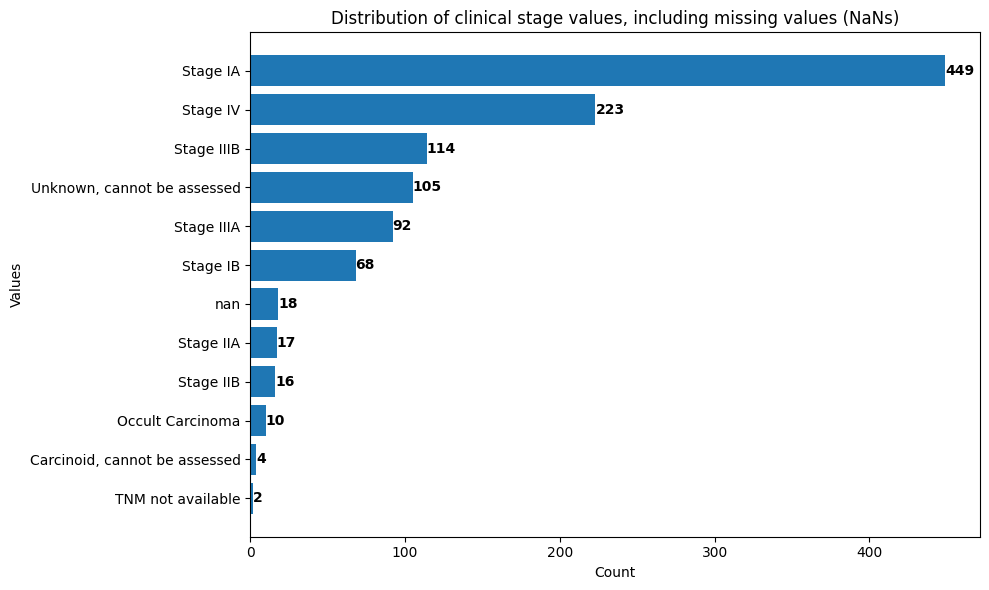

In [11]:
# plot histogram of values in nlst_clinical_df['clinical_stag_meaning'] by count,
# including NaN as a separate item

# Assuming your DataFrame is named 'df' and the column is named 'column_name'

# Count values including NaNs
value_counts = with_images['clinical_stag_meaning'].value_counts(dropna=False)

# Create horizontal bar plot
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(value_counts.index.astype(str), value_counts.values)

# Add labels to the bars
for bar in bars:
    width = bar.get_width()
    ax.text(width, bar.get_y() + bar.get_height()/2, f'{width}',
            ha='left', va='center', fontweight='bold')

# Customize the plot
plt.title('Distribution of clinical stage values, including missing values (NaNs)')
plt.xlabel('Count')
plt.ylabel('Values')

# Adjust layout and display the plot
plt.tight_layout()
plt.gca().invert_yaxis()
plt.show()

In [12]:
print(f'Attributes in IDC index: \n{c.index.dtypes}\n')

Attributes in IDC index: 
collection_id             object
analysis_result_id        object
PatientID                 object
SeriesInstanceUID         object
StudyInstanceUID          object
source_DOI                object
PatientAge                object
PatientSex                object
StudyDate                 object
StudyDescription          object
BodyPartExamined          object
Modality                  object
Manufacturer              object
ManufacturerModelName     object
SeriesDate                object
SeriesDescription         object
SeriesNumber              object
instanceCount              Int64
license_short_name        object
aws_bucket                object
crdc_series_uuid          object
series_aws_url            object
series_size_MB           float64
dtype: object



In [47]:
patient_ages = c.index[c.index['collection_id']=='nlst'][['PatientAge']].value_counts()
print(patient_ages)

PatientAge
068Y          99
059Y          88
064Y          87
065Y          80
058Y          72
061Y          68
060Y          68
067Y          67
063Y          66
062Y          64
056Y          62
073Y          60
072Y          57
070Y          56
066Y          55
069Y          54
057Y          49
055Y          44
071Y          37
074Y          26
Name: count, dtype: int64


In [14]:
my_ProjectID = "nlst-radiomics"

import os
os.environ["GCP_PROJECT_ID"] = my_ProjectID

from google.colab import auth
auth.authenticate_user()

In [15]:
%%bigquery --project=$my_ProjectID

SELECT COUNT(DISTINCT(collection_id)) as collections_cnt
FROM bigquery-public-data.idc_current.dicom_all

Query is running:   0%|          |

Downloading:   0%|          |

,collections_cnt
0,161


In [16]:
from google.cloud import bigquery

bq_client = bigquery.Client(my_ProjectID)

selection_query = """
SELECT DISTINCT Manufacturer, ManufacturerModelName
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst' AND Modality = 'CT'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,Manufacturer,ManufacturerModelName
0,GE MEDICAL SYSTEMS,LightSpeed16
1,SIEMENS,Sensation 64
2,GE MEDICAL SYSTEMS,Discovery QX/i
3,GE MEDICAL SYSTEMS,LightSpeed Power
4,GE MEDICAL SYSTEMS,CT scan
5,GE MEDICAL S]STEMS,LightSpeed QX/i
6,GE MEDICAL SYSTEMS,LightSpeed Plus
7,GE MEDICAL SYSTEMS,LightSpeed Pro 16
8,GE MEDICAL SYSTEMS,Discovery LS
9,SIEMENS,Emotion 16


In [17]:
selection_query = """
SELECT
  COUNT(DISTINCT PatientID) AS num_patients,
  COUNT(DISTINCT StudyInstanceUID) AS num_studies,
  COUNT(DISTINCT SeriesInstanceUID) AS num_series,
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,num_patients,num_studies,num_series
0,26410,73574,590572


In [26]:
selection_query = """
SELECT
  COUNT(DISTINCT PatientSex) AS num_sex,
  COUNT(DISTINCT PatientAge) AS num_age,
  COUNT(DISTINCT EthnicGroup) AS num_ethnic_groups,
  COUNT(DISTINCT PatientWeight) AS num_weight,
  COUNT(DISTINCT InstitutionName) AS num_imaging_centers,
  COUNT(DISTINCT InstitutionAddress) AS num_imaging_center_addresses,
  COUNT(DISTINCT ClinicalTrialCoordinatingCenterName) AS num_clinical_trial_centers
FROM bigquery-public-data.idc_current.dicom_all
WHERE collection_id = 'nlst'
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,num_sex,num_age,num_ethnic_groups,num_weight,num_imaging_centers,num_imaging_center_addresses,num_clinical_trial_centers
0,2,20,6,0,0,0,2


In [32]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [38]:
# INCORRECT: WHY?

selection_query = """
WITH raw AS (
  SELECT
    PatientID,
    SAFE_CAST(REGEXP_EXTRACT(PatientAge, r'([0-9]+)') AS INT64) AS age,
    PatientSex,
    EthnicGroup
  FROM `bigquery-public-data.idc_current.dicom_all`
),

patients AS (
  SELECT
    PatientID,
    MAX(age) AS age,
    MAX(PatientSex) AS PatientSex,
    MAX(EthnicGroup) AS EthnicGroup
  FROM raw
  GROUP BY PatientID
),

totals AS (
  SELECT COUNT(*) AS total_patients
  FROM patients
),

age_groups AS (
  SELECT
    PatientID,
    CASE
      WHEN age IS NULL THEN 'Unknown'
      WHEN age < 55 THEN '<55'
      WHEN age BETWEEN 55 AND 59 THEN '55-59'
      WHEN age BETWEEN 60 AND 64 THEN '60-64'
      WHEN age BETWEEN 65 AND 69 THEN '65-69'
      WHEN age BETWEEN 70 AND 74 THEN '70-74'
      WHEN age >= 75 THEN '>=75'
    END AS age_group,
    PatientSex,
    EthnicGroup
  FROM patients
),

unioned AS (
  SELECT
    'Age Groups' AS category,
    age_group AS value,
    COUNT(*) AS count,
    ROUND(100 * COUNT(*) / total_patients, 2) AS percent
  FROM age_groups, totals
  GROUP BY age_group, total_patients

  UNION ALL

  SELECT
    'Sex' AS category,
    COALESCE(PatientSex, 'Unknown') AS value,
    COUNT(*) AS count,
    ROUND(100 * COUNT(*) / total_patients, 2) AS percent
  FROM age_groups, totals
  GROUP BY PatientSex, total_patients

  UNION ALL

  SELECT
    'Ethnic Group' AS category,
    COALESCE(EthnicGroup, 'Unknown') AS value,
    COUNT(*) AS count,
    ROUND(100 * COUNT(*) / total_patients, 2) AS percent
  FROM age_groups, totals
  GROUP BY EthnicGroup, total_patients
)

SELECT *
FROM unioned
ORDER BY category, value;
"""

selection_result = bq_client.query(selection_query)
selection_df = selection_result.result().to_dataframe()

selection_df

,category,value,count,percent
0,Age Groups,55-59,2516,3.15
1,Age Groups,60-64,2549,3.19
2,Age Groups,65-69,2481,3.11
3,Age Groups,70-74,1645,2.06
4,Age Groups,<55,7941,9.94
5,Age Groups,>=75,5525,6.92
6,Age Groups,Unknown,57232,71.64
7,Ethnic Group,01,18,0.02
8,Ethnic Group,02,3,0.00
9,Ethnic Group,1,24,0.03
